<a href="https://colab.research.google.com/github/dhruvsuri8106-code/ECON-3916---Statistical-and-Machine-Learning/blob/main/Assignment%203%20/%20Econ_3916_Assignment_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
np.random.seed(42)
zeros = np.zeros(100)
tips = np.random.exponential(scale=5.0, size=150)
driver_tips = np.concatenate([zeros, tips])

In [10]:
import numpy as np

# number of bootstrap samples
num_samples = 10000

# array to store all the medians
medians = []

n = len(driver_tips)

# bootstrap loop
for i in range(num_samples):

    # take a random sample WITH replacement
    sample = np.random.choice(driver_tips, size=n, replace=True)

    # compute the median of this sample
    m = np.median(sample)

    # store it
    medians.append(m)

medians = np.array(medians)
lower = np.percentile(boot_medians, 2.5)
upper = np.percentile(boot_medians, 97.5)

print("Median estimate:", np.median(driver_tips))
print("95% Confidence Interval:", lower, upper)

Median estimate: 0.7553316913699188
95% Confidence Interval: 0.2813941876211842 1.3635639228066991


In [11]:
import numpy as np
np.random.seed(42)
control = np.random.normal(loc=35, scale=5, size=500)
treatment = np.random.lognormal(mean=3.4, sigma=0.4, size=500)
observed_diff = np.mean(control) - np.mean(treatment)


print(observed_diff)

2.2649821306257394


In [12]:
import numpy as np

np.random.seed(42)

control = np.random.normal(loc=35, scale=5, size=500)
treatment = np.random.lognormal(mean=3.4, sigma=0.4, size=500)
observed_diff = np.mean(control) - np.mean(treatment)

all_deliveries = np.concatenate([control, treatment])
perm_diffs = []

iterations = 5000

for i in range(iterations):

    shuffled = np.random.permutation(all_deliveries)
    group1 = shuffled[:500]
    group2 = shuffled[500:]
    diff = np.mean(group1) - np.mean(group2)

    perm_diffs.append(diff)

perm_diffs = np.array(perm_diffs)


extreme = np.sum(np.abs(perm_diffs) >= abs(observed_diff))
p_value = extreme / iterations

print("Observed difference:", observed_diff)
print("Empirical p-value:", p_value)

Observed difference: 2.2649821306257394
Empirical p-value: 0.0004


This is not more extreme than my observed emperical difference.

In [13]:
df = pd.read_csv('swiftcart_loyalty.csv')

In [19]:
df

,subscriber,pre_spend,account_age,support_tickets,post_spend
0,1,57.450712,37,2,85.169648
1,1,47.926035,41,0,72.802404
2,1,59.715328,41,0,79.858905
3,1,72.845448,34,0,80.335466
4,1,46.487699,34,2,67.956227
...,...,...,...,...,...
8936,1,35.172065,51,0,55.662507
8937,1,83.613898,5,2,94.767676
8938,0,57.146453,6,2,58.616370
8939,0,47.701092,13,0,60.069619


In [15]:
subscribers = df[df["subscriber"] == 1]["post_spend"].mean()
non_subscribers = df[df["subscriber"] == 0]["post_spend"].mean()
print (subscribers - non_subscribers)


17.57066938452379


In [20]:
X = df[["pre_spend", "account_age", "support_tickets"]]
y = df["subscriber"]
model = LogisticRegression(max_iter=1000)
model.fit(X, y)
df["propensity_score"] = model.predict_proba(X)[:,1]

In [24]:
treated = df[df["subscriber"] == 1]
control = df[df["subscriber"] == 0]
nn = NearestNeighbors(n_neighbors=1)
nn.fit(control[["propensity_score"]])
distances, indices = nn.kneighbors(treated[["propensity_score"]])
matched_controls = control.iloc[indices.flatten()]
treated_spend = treated["post_spend"].values
control_spend = matched_controls["post_spend"].values
ATT = np.mean(treated_spend - control_spend)
print(ATT)


9.913855182824864


Naive SDO: 17.57066938452379
ATT: 9.913855182824864


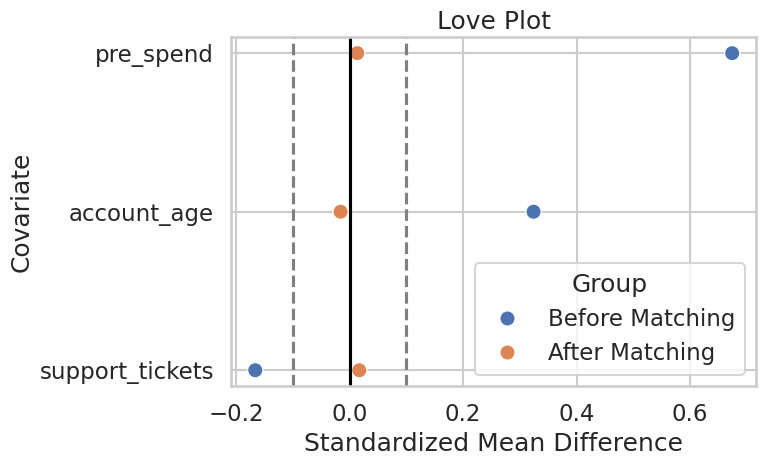

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors

# load the data
df = pd.read_csv("swiftcart_loyalty.csv")

# -------------------------
# 1. NAIVE SIMPLE DIFFERENCE
# -------------------------

mean_sub = df[df["subscriber"] == 1]["post_spend"].mean()
mean_non = df[df["subscriber"] == 0]["post_spend"].mean()

SDO = mean_sub - mean_non

print("Naive SDO:", SDO)

# -------------------------
# 2. PROPENSITY SCORES
# -------------------------

# use only pre-treatment covariates
X = df[["pre_spend", "account_age", "support_tickets"]]
y = df["subscriber"]

logit = LogisticRegression(max_iter=1000)
logit.fit(X, y)

df["propensity_score"] = logit.predict_proba(X)[:, 1]

# -------------------------
# 3. MATCHING
# -------------------------

treated = df[df["subscriber"] == 1].copy()
control = df[df["subscriber"] == 0].copy()

nn = NearestNeighbors(n_neighbors=1)
nn.fit(control[["propensity_score"]])

distances, indices = nn.kneighbors(treated[["propensity_score"]])

matched_controls = control.iloc[indices.flatten()].copy()

# make one matched dataset
df_matched = pd.concat([treated, matched_controls], axis=0).reset_index(drop=True)

# original unmatched dataset
df_unmatched = df.copy()

# -------------------------
# 4. ATT
# -------------------------

treated_post = treated["post_spend"].values
matched_control_post = matched_controls["post_spend"].values

ATT = np.mean(treated_post - matched_control_post)

print("ATT:", ATT)

# -------------------------
# 5. LOVE PLOT
# -------------------------

def get_smd(data, variable):
    treated_group = data[data["subscriber"] == 1][variable]
    control_group = data[data["subscriber"] == 0][variable]

    mean_t = treated_group.mean()
    mean_c = control_group.mean()

    var_t = treated_group.var()
    var_c = control_group.var()

    pooled_sd = np.sqrt((var_t + var_c) / 2)

    if pooled_sd == 0:
        return 0

    return (mean_t - mean_c) / pooled_sd

covariates = ["pre_spend", "account_age", "support_tickets"]

before_list = []
after_list = []

for var in covariates:
    before_smd = get_smd(df_unmatched, var)
    after_smd = get_smd(df_matched, var)

    before_list.append(before_smd)
    after_list.append(after_smd)

plot_df = pd.DataFrame({
    "covariate": covariates,
    "Before Matching": before_list,
    "After Matching": after_list
})

plot_long = plot_df.melt(
    id_vars="covariate",
    var_name="Group",
    value_name="SMD"
)

sns.set_style("whitegrid")
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=plot_long,
    x="SMD",
    y="covariate",
    hue="Group",
    s=120
)

plt.axvline(0, color="black")
plt.axvline(0.1, color="gray", linestyle="--")
plt.axvline(-0.1, color="gray", linestyle="--")

plt.title("Love Plot")
plt.xlabel("Standardized Mean Difference")
plt.ylabel("Covariate")
plt.tight_layout()
plt.show()